In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np


In [3]:
# parquet dosyalarını sıralı şekilde alıyorum
files = sorted(glob.glob("../data/*.parquet"))
print(files)

['../data/yellow_tripdata_2015-01.parquet', '../data/yellow_tripdata_2015-02.parquet', '../data/yellow_tripdata_2015-03.parquet', '../data/yellow_tripdata_2015-04.parquet', '../data/yellow_tripdata_2015-05.parquet', '../data/yellow_tripdata_2015-06.parquet', '../data/yellow_tripdata_2015-07.parquet', '../data/yellow_tripdata_2015-08.parquet', '../data/yellow_tripdata_2015-09.parquet', '../data/yellow_tripdata_2015-10.parquet', '../data/yellow_tripdata_2015-11.parquet', '../data/yellow_tripdata_2015-12.parquet']


In [4]:
# İlk olarak sadece ocak ayı verisini inceliyorum
df_january = pd.read_parquet("../data/yellow_tripdata_2015-01.parquet")
df_january.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.0,1,N,41,166,1,5.7,0.5,0.5,1.40,0.0,0.0,8.40,None,None
1,1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.9,1,N,166,238,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None
2,1,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.5,1,N,238,162,1,13.2,0.5,0.5,2.90,0.0,0.0,17.40,None,None
3,1,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.1,1,N,162,263,1,8.2,0.5,0.5,2.37,0.0,0.0,11.87,None,None
4,1,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.0,1,N,236,141,3,6.0,0.5,0.5,0.00,0.0,0.0,7.30,None,None


# Veriye genel bakış


In [5]:
# satır ve sütun sayısının kontrol edilmesi
df_january.shape

(12741035, 19)

In [6]:
# sütun isimlerini kontrol ediyorum
df_january.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='str')

In [7]:
# veri tiplerinin kontrol edilmesi
df_january.dtypes

VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                   int64
trip_distance                   float64
RatecodeID                        int64
store_and_fwd_flag                  str
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge             object
airport_fee                      object
dtype: object

In [8]:
# eksik değerleri kontrol ediyorum
df_january.isnull().sum()

VendorID                        0
tpep_pickup_datetime            0
tpep_dropoff_datetime           0
passenger_count                 0
trip_distance                   0
RatecodeID                      0
store_and_fwd_flag              0
PULocationID                    0
DOLocationID                    0
payment_type                    0
fare_amount                     0
extra                           0
mta_tax                         0
tip_amount                      0
tolls_amount                    0
improvement_surcharge           3
total_amount                    0
congestion_surcharge     12741035
airport_fee              12741035
dtype: int64

In [9]:
# pickup sütununu datetime türüne dönüştürüyorum
df_january["tpep_pickup_datetime"] = pd.to_datetime(
    df_january["tpep_pickup_datetime"],
    errors="coerce")
# Ocak ayı için saatlik trip sayısını hesaplıyorum
january_hourly = (
    df_january.set_index("tpep_pickup_datetime")
    .resample("h")
    .size()
    .reset_index(name="trip_count"))
january_hourly.head()

,tpep_pickup_datetime,trip_count
0,2015-01-01 00:00:00,28312
1,2015-01-01 01:00:00,31707
2,2015-01-01 02:00:00,28068
3,2015-01-01 03:00:00,24288
4,2015-01-01 04:00:00,17081


### Aylık dosyaların eklenmesi


In [10]:
all_data = []

for file in files:

    print("Reading:", file)

    temp_df = pd.read_parquet(
        file,
        columns=[
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "passenger_count",
            "trip_distance",
            "fare_amount",
            "tip_amount",
            "tolls_amount",
            "total_amount",
            "payment_type",
            "RatecodeID"
        ]
    )

    all_data.append(temp_df)
df = pd.concat(all_data, ignore_index=True)
print(df.shape)

Reading: ../data/yellow_tripdata_2015-01.parquet
Reading: ../data/yellow_tripdata_2015-02.parquet
Reading: ../data/yellow_tripdata_2015-03.parquet
Reading: ../data/yellow_tripdata_2015-04.parquet
Reading: ../data/yellow_tripdata_2015-05.parquet
Reading: ../data/yellow_tripdata_2015-06.parquet
Reading: ../data/yellow_tripdata_2015-07.parquet
Reading: ../data/yellow_tripdata_2015-08.parquet
Reading: ../data/yellow_tripdata_2015-09.parquet
Reading: ../data/yellow_tripdata_2015-10.parquet
Reading: ../data/yellow_tripdata_2015-11.parquet
Reading: ../data/yellow_tripdata_2015-12.parquet
(146039231, 10)


In [11]:
# Sayısal sütunların temel istatistiklerini inceliyorum
df.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,payment_type,RatecodeID
count,146039231,146039231,1.460392e+08,1.460392e+08,1.460392e+08,1.460392e+08,1.460392e+08,1.460392e+08,1.460392e+08,1.460392e+08
mean,2015-06-26 17:29:12.342669,2015-06-26 17:48:55.793451,1.680858e+00,1.184584e+01,1.293904e+01,1.729140e+00,3.077635e-01,1.609726e+01,1.378856e+00,1.041786e+00
min,2015-01-01 00:00:00,1900-01-01 00:00:00,0.000000e+00,-4.084012e+07,-4.960000e+02,-4.400000e+02,-9.900000e+01,-4.963000e+02,1.000000e+00,1.000000e+00
25%,2015-03-27 13:26:37,2015-03-27 13:42:54.500000,1.000000e+00,1.000000e+00,6.500000e+00,0.000000e+00,0.000000e+00,8.750000e+00,1.000000e+00,1.000000e+00
50%,2015-06-20 18:28:43,2015-06-20 18:43:56,1.000000e+00,1.710000e+00,9.500000e+00,1.160000e+00,0.000000e+00,1.180000e+01,1.000000e+00,1.000000e+00
75%,2015-09-26 23:56:36,2015-09-27 00:12:53,2.000000e+00,3.200000e+00,1.450000e+01,2.300000e+00,0.000000e+00,1.780000e+01,2.000000e+00,1.000000e+00
max,2015-12-31 23:59:59,2253-08-23 07:56:38,9.000000e+00,5.901661e+07,8.259986e+05,3.950589e+06,1.901400e+03,3.950612e+06,5.000000e+00,9.900000e+01
std,NaN,NaN,1.333530e+00,1.093597e+04,1.243789e+02,3.269192e+02,1.646136e+00,3.569951e+02,4.991914e-01,6.533164e-01


In [12]:
# sayısal sütunların min, max, mean ve median değerlerini kontrol ediyorum
numeric_columns = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "tolls_amount",
    "total_amount",
]
for col in numeric_columns:

    print("\nColumn:", col)

    print("Minimum:", df[col].min())

    print("Maximum:", df[col].max())

    print("Mean:", df[col].mean())

    print("Median:", df[col].median())


Column: passenger_count
Minimum: 0
Maximum: 9
Mean: 1.6808580976436394
Median: 1.0

Column: trip_distance
Minimum: -40840124.4
Maximum: 59016609.3
Mean: 11.845839219462885
Median: 1.71

Column: fare_amount
Minimum: -496.0
Maximum: 825998.61
Mean: 12.939035017035936
Median: 9.5

Column: tip_amount
Minimum: -440.0
Maximum: 3950588.8
Mean: 1.7291397760099132
Median: 1.16

Column: tolls_amount
Minimum: -99.0
Maximum: 1901.4
Mean: 0.3077634806910206
Median: 0.0

Column: total_amount
Minimum: -496.3
Maximum: 3950611.6
Mean: 16.09725554950368
Median: 11.8


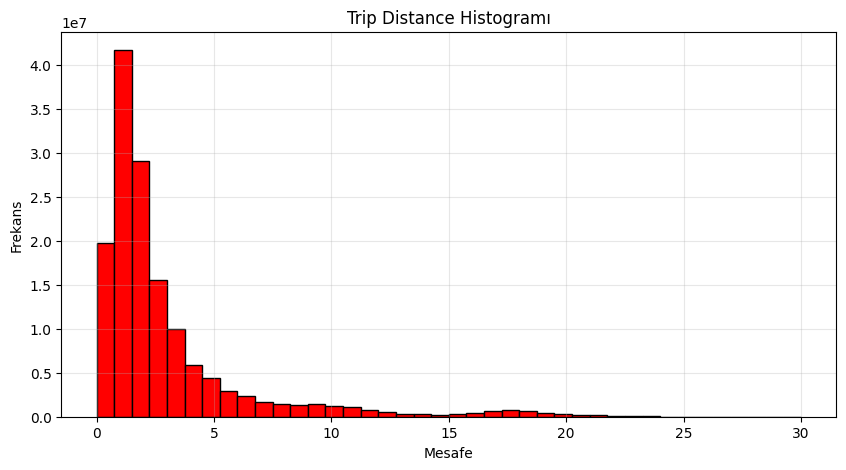

In [13]:

# veri temizliği öncesi histogram 
plt.figure(figsize=(10,5))

plt.hist(
    df["trip_distance"],
    bins=40,
    range=(0, 30),
    edgecolor="black",
    color ="red")
plt.title("Trip Distance Histogramı")
plt.xlabel("Mesafe")
plt.ylabel("Frekans")
plt.grid(alpha=0.3)
plt.show()

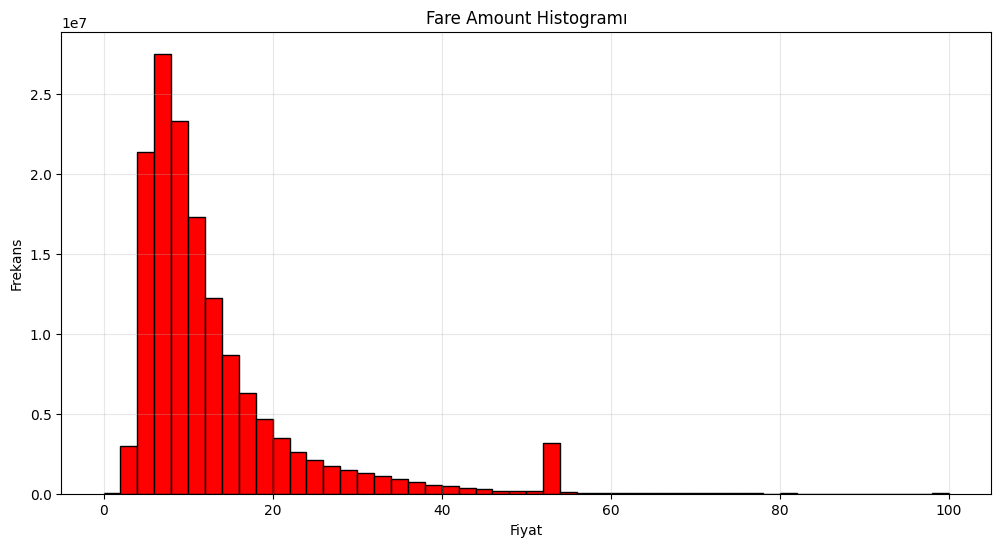

In [14]:
# fare amount temizliği öncesi histogram
plt.figure(figsize=(12,6))

plt.hist(
    df["fare_amount"],
    bins=50,
    range=(0,100),
    edgecolor="black",
    color ="red"
)
plt.title("Fare Amount Histogramı")
plt.xlabel("Fiyat")
plt.ylabel("Frekans")
plt.grid(alpha=0.3)
plt.show()

In [15]:
# # negatif ve mantıksız değerleri kontrol ettikten sonra outlier temizleme işlemlerinde IQR yöntemini kullandım
print("Passenger count <= 0:", (df["passenger_count"] <= 0).sum())

print("Trip distance <= 0:", (df["trip_distance"] <= 0).sum())

print("Fare amount <= 0:", (df["fare_amount"] <= 0).sum())

print("Negative tip amounts:", (df["tip_amount"] < 0).sum())



Passenger count <= 0: 40683
Trip distance <= 0: 876729
Fare amount <= 0: 87046
Negative tip amounts: 1008


# veride çok fazla aykırı değer bulunduğu için outlier temizleme işleminde IQR yöntemini kullanıyorum

In [16]:
# IQR için kontrol edilecek sayısal sütunlar: tolls amaount ve passenger count çıkarıldı. 
# tolss amaountta lower ve upper 0 gözüktü datasette çoğu yolculuk toll road kullanmadığı için kaldırdım. 
# passenger count'u ise lower boundda -4 değeri ve upper bounnda 7 değeri çıktı ben zaten bunu <= 5 olarak sınırlandırmıştım.
iqr_columns = [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
]
iqr_bounds = {}
for col in iqr_columns:
    # Q1 ve Q3 değerlerini hesaplıyorum
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
   
    IQR = Q3 - Q1

    # daha esnek sınırlar için 1.5 yerine 5* kullandım
    lower_bound = Q1 - 5 * IQR
    upper_bound = Q3 + 5 * IQR

    # alt ve üst sınırları kaydedilmesi
    iqr_bounds[col] = (
        lower_bound,
        upper_bound)
    print(col)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print()

trip_distance
Lower bound: -10.0
Upper bound: 14.2

fare_amount
Lower bound: -33.5
Upper bound: 54.5

tip_amount
Lower bound: -11.5
Upper bound: 13.8

total_amount
Lower bound: -36.5
Upper bound: 63.05



In [17]:
# IQR sınırlarına göre temizleme koşullarını oluşturuyorum
condition = (
    (df["passenger_count"] > 0) &
    (df["passenger_count"] <= 5) &
    (df["trip_distance"] > 0) &
    (df["fare_amount"] > 0) &
    (df["tip_amount"] >= 0) &
    (df["total_amount"] > 0)
)

for col in iqr_columns:

    lower_bound, upper_bound = iqr_bounds[col]

    condition = condition & (
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    )

df_clean = df.loc[condition].copy()

print("Before cleaning:", df.shape)
print("After cleaning:", df_clean.shape)

Before cleaning: (146039231, 10)
After cleaning: (135538755, 10)


In [18]:
# # pickup datetime sütununu datetime formatına dönüştürülmesi
df_clean["tpep_pickup_datetime"] = pd.to_datetime(
    df_clean["tpep_pickup_datetime"],
    errors="coerce" )
# dropoff datetime sütununu datetime formatına dönüştürüyorum
df_clean["tpep_dropoff_datetime"] = pd.to_datetime(
    df_clean["tpep_dropoff_datetime"],
    errors="coerce")
# boş datetime değerlerini kaldırıyorum
df_clean = df_clean.dropna(
    subset=[
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime"
    ])
# sadece 2015 yılı içindeki verileri tutuyorum
df_clean = df_clean[
    (df_clean["tpep_pickup_datetime"] >= "2015-01-01") &
    (df_clean["tpep_pickup_datetime"] < "2016-01-01") ]
print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (135538755, 10)


In [19]:
df_clean.describe()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,payment_type,RatecodeID
count,135538755,135538755,1.355388e+08,1.355388e+08,1.355388e+08,1.355388e+08,1.355388e+08,1.355388e+08,1.355388e+08,1.355388e+08
mean,2015-06-26 12:48:07.213985,2015-06-26 13:08:02.332855,1.523146e+00,2.513792e+00,1.154340e+01,1.515139e+00,1.741112e-01,1.435502e+01,1.377099e+00,1.003925e+00
min,2015-01-01 00:00:00,1973-05-09 09:17:59,1.000000e+00,1.000000e-02,1.000000e-02,0.000000e+00,-5.540000e+00,1.000000e-02,1.000000e+00,1.000000e+00
25%,2015-03-27 05:52:07,2015-03-27 06:04:41.500000,1.000000e+00,1.000000e+00,6.500000e+00,0.000000e+00,0.000000e+00,8.320000e+00,1.000000e+00,1.000000e+00
50%,2015-06-20 11:58:21,2015-06-20 12:11:42,1.000000e+00,1.700000e+00,9.500000e+00,1.150000e+00,0.000000e+00,1.176000e+01,1.000000e+00,1.000000e+00
75%,2015-09-26 22:50:07,2015-09-26 23:06:07,2.000000e+00,3.000000e+00,1.400000e+01,2.250000e+00,0.000000e+00,1.700000e+01,2.000000e+00,1.000000e+00
max,2015-12-31 23:59:59,2253-08-23 07:56:38,5.000000e+00,1.420000e+01,5.450000e+01,1.380000e+01,6.000000e+01,6.305000e+01,5.000000e+00,9.900000e+01
std,NaN,NaN,1.067810e+00,2.389599e+00,7.318186e+00,1.810862e+00,9.753377e-01,8.940231e+00,4.954371e-01,3.569590e-01


In [20]:
df_clean

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,payment_type,RatecodeID
0,2015-01-01 00:11:33,2015-01-01 00:16:48,1,1.00,5.7,1.40,0.0,8.40,1,1
1,2015-01-01 00:18:24,2015-01-01 00:24:20,1,0.90,6.0,0.00,0.0,7.30,3,1
2,2015-01-01 00:26:19,2015-01-01 00:41:06,1,3.50,13.2,2.90,0.0,17.40,1,1
3,2015-01-01 00:45:26,2015-01-01 00:53:20,1,2.10,8.2,2.37,0.0,11.87,1,1
4,2015-01-01 00:59:21,2015-01-01 01:05:24,1,1.00,6.0,0.00,0.0,7.30,3,1
...,...,...,...,...,...,...,...,...,...,...
146039226,2015-12-31 23:35:31,2015-12-31 23:53:32,1,4.50,16.5,10.00,0.0,27.80,1,1
146039227,2015-12-31 23:57:59,2016-01-01 00:01:23,2,0.50,4.5,1.15,0.0,6.95,1,1
146039228,2015-12-31 23:14:15,2015-12-31 23:29:44,1,2.69,12.0,0.00,0.0,13.30,2,1
146039229,2015-12-31 23:54:50,2016-01-01 00:03:52,1,1.35,8.0,1.86,0.0,11.16,1,1


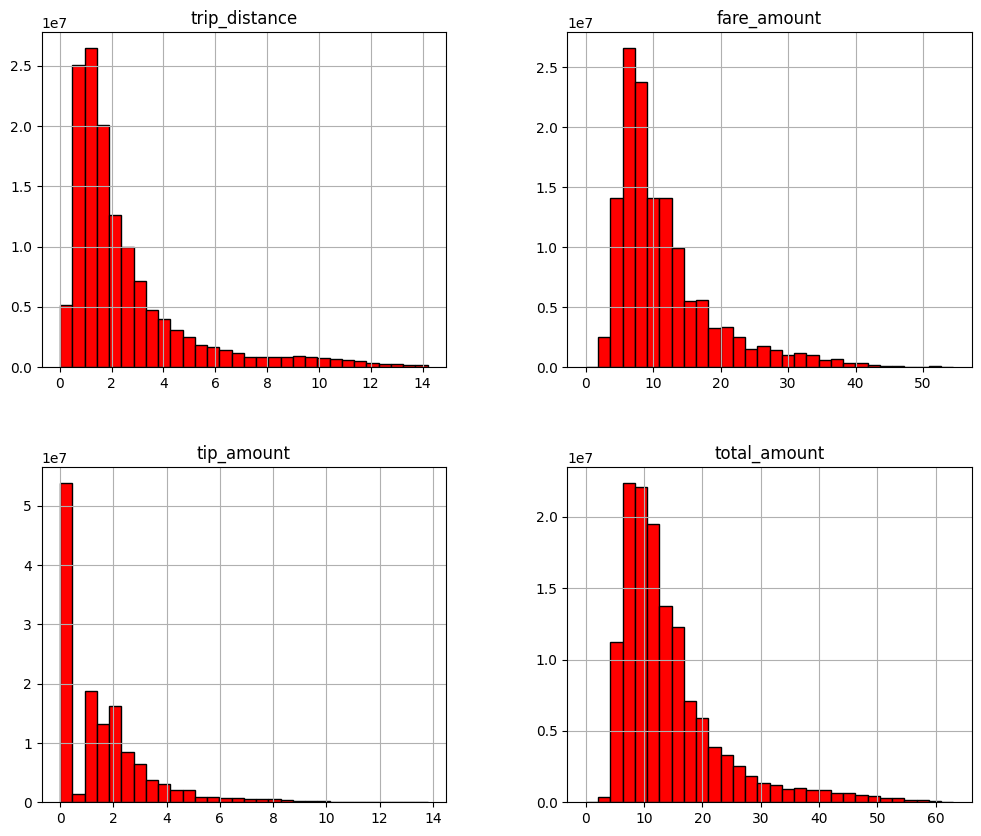

In [21]:
df_clean[
    [
        "trip_distance",
        "fare_amount",
        "tip_amount",
        "total_amount"
    ]
].hist(
    figsize=(12,10),
    bins=30,
    edgecolor="black",
    color="red")
plt.show()

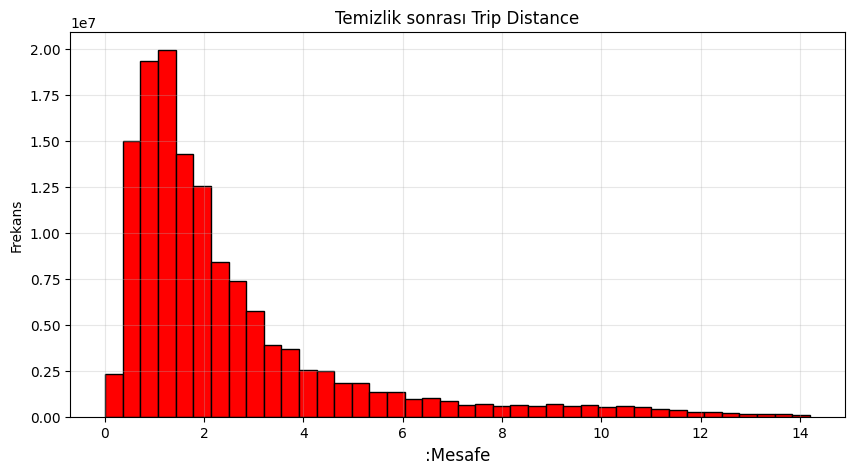

In [22]:
# IQR temizliği sonrası sonrası histogram
plt.figure(figsize=(10,5))

plt.hist(
    df_clean["trip_distance"],
    bins=40,
    edgecolor="black",
    color="red")
plt.xlabel(
    ":Mesafe",
    fontsize=12)
plt.grid(alpha=0.3)
plt.ylabel(
    "Frekans",
    fontsize=10)
plt.title("Temizlik sonrası Trip Distance")
plt.show()

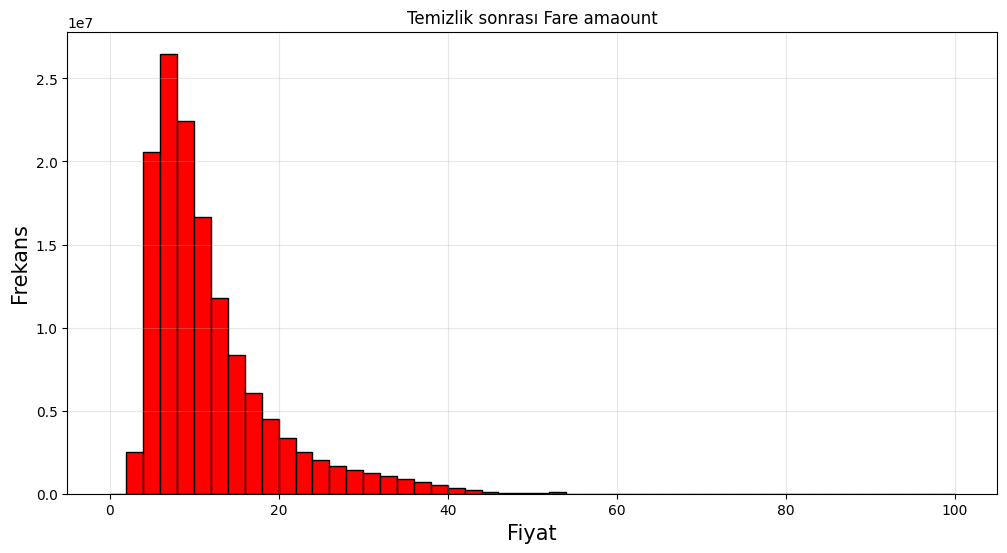

In [23]:
# fare amount histogram
plt.figure(figsize=(12,6))

plt.hist(
    df_clean["fare_amount"],
    bins=50,
    range=(0,100),
    edgecolor="black",
    color="red")

plt.title("Temizlik sonrası Fare amaount")
plt.xlabel(
    "Fiyat",
    fontsize=15)
plt.ylabel(
    "Frekans",
    fontsize=15)
plt.grid(alpha=0.3)
plt.show()

# Z-Score
## Bu yöntem, değerlerin ortalamadan kaç standart sapma uzak olduğunu gösterir.
## z = (x - μ) / σ
## x= veri değeri, μ = ortalama, σ = standart sapma

In [24]:
#alttaki kütüphane formülü otomatik hesaplıyor.
from scipy.stats import zscore

# Z-score hesaplanırken yeni sütunlar eklendiği için ana temiz veri setini bozmamak adına df_clean verisinin kopyasını oluşturdum
df_zscore = df_clean.copy()

# Z-score hesaplanacak sütunlar
zscore_columns = [
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount"
]
# Her sütun için z-score değerlerini hesaplanması
for col in zscore_columns:
    df_zscore[col + "_zscore"] = zscore(
        df_zscore[col]
)

# |z-score| > 4 olan değerleri aykırı değer olarak kontrol ediyorum
for col in zscore_columns:
    outlier_count = (
        df_zscore[col + "_zscore"].abs() > 4
    ).sum()
    print(col, "Z-score outliers:", outlier_count)

trip_distance Z-score outliers: 990953
fare_amount Z-score outliers: 656894
tip_amount Z-score outliers: 1071645
total_amount Z-score outliers: 1075069


###  -- Z-score yöntemi IQR yöntemine göre daha fazla outlier tespit etti. Bu yöntem IQR yöntemine göre daha fazla aykırı değer buldu.

## Yıl boyu saatlik trip sayısı

In [25]:
#  saatlik trip sayısını hesaplanması
hourly_data = (
    df_clean[["tpep_pickup_datetime"]]
    .copy()
)
hourly_data["pickup_hour"] = hourly_data["tpep_pickup_datetime"].dt.floor("h")
hourly_data = (
    hourly_data
    .groupby("pickup_hour")
    .size()
    .reset_index(name="trip_count"))
hourly_data = hourly_data.rename(
    columns={"pickup_hour": "tpep_pickup_datetime"})
hourly_data.head()

,tpep_pickup_datetime,trip_count
0,2015-01-01 00:00:00,26863
1,2015-01-01 01:00:00,30023
2,2015-01-01 02:00:00,26474
3,2015-01-01 03:00:00,22833
4,2015-01-01 04:00:00,15841


### Saatlik veriyi oluşturduktan sonra kayıtları tpep_pickup_datetime sütununa göre sıraladım. Böylece veri Ocak 2015'ten Aralık 2015'e kadar kronolojik sırada tutuldu

In [26]:
# veriyi tarihe göre sıraladım
hourly_data = hourly_data.sort_values(
    by="tpep_pickup_datetime"
).reset_index(drop=True)

hourly_data.head()

,tpep_pickup_datetime,trip_count
0,2015-01-01 00:00:00,26863
1,2015-01-01 01:00:00,30023
2,2015-01-01 02:00:00,26474
3,2015-01-01 03:00:00,22833
4,2015-01-01 04:00:00,15841


In [27]:
hourly_data.tail()

,tpep_pickup_datetime,trip_count
8755,2015-12-31 19:00:00,19932
8756,2015-12-31 20:00:00,21571
8757,2015-12-31 21:00:00,22496
8758,2015-12-31 22:00:00,20129
8759,2015-12-31 23:00:00,16275


In [28]:
hourly_data.describe()

,tpep_pickup_datetime,trip_count
count,8760,8760.000000
mean,2015-07-02 11:30:00,15472.460616
min,2015-01-01 00:00:00,13.000000
25%,2015-04-02 05:45:00,10352.000000
50%,2015-07-02 11:30:00,17121.500000
75%,2015-10-01 17:15:00,20310.250000
max,2015-12-31 23:00:00,43452.000000
std,NaN,7020.842424


In [29]:
hourly_data.shape

(8760, 2)

In [30]:
# saatlik trip count verisini csv olarak kaydediyorum
hourly_data.to_csv(
    "../outputs/hourly_trip_counts_2015.csv",
    index=False)
print("CSV dosyası kaydedildi")

CSV dosyası kaydedildi


# Feature Engineering


In [31]:
# -- saat ve takvim bilgisi --
hourly_data["pickup_hour"]      = hourly_data["tpep_pickup_datetime"].dt.hour
hourly_data["pickup_dayofweek"] = hourly_data["tpep_pickup_datetime"].dt.dayofweek
hourly_data["pickup_month"]     = hourly_data["tpep_pickup_datetime"].dt.month
hourly_data["pickup_day"]       = hourly_data["tpep_pickup_datetime"].dt.day

In [32]:
# saat için cyclic encoding
hourly_data["hour_sin"] = np.sin(2 * np.pi * hourly_data["pickup_hour"] / 24)
hourly_data["hour_cos"] = np.cos(2 * np.pi * hourly_data["pickup_hour"] / 24)
# haftanın günü için cyclic encoding
hourly_data["day_sin"] = np.sin(2 * np.pi * hourly_data["pickup_dayofweek"] / 7)
hourly_data["day_cos"] = np.cos(2 * np.pi * hourly_data["pickup_dayofweek"] / 7)
# ay için cyclic encoding
hourly_data["month_sin"] = np.sin(2 * np.pi * hourly_data["pickup_month"] / 12)
hourly_data["month_cos"] = np.cos(2 * np.pi * hourly_data["pickup_month"] / 12)

In [33]:
hourly_data[
    [ "pickup_hour",
        "hour_sin",
        "hour_cos",
        "pickup_dayofweek",
        "day_sin",
        "day_cos",
        "pickup_month",
        "month_sin",
        "month_cos"]
].head()

,pickup_hour,hour_sin,hour_cos,pickup_dayofweek,day_sin,day_cos,pickup_month,month_sin,month_cos
0,0,0.000000,1.000000,3,0.433884,-0.900969,1,0.5,0.866025
1,1,0.258819,0.965926,3,0.433884,-0.900969,1,0.5,0.866025
2,2,0.500000,0.866025,3,0.433884,-0.900969,1,0.5,0.866025
3,3,0.707107,0.707107,3,0.433884,-0.900969,1,0.5,0.866025
4,4,0.866025,0.500000,3,0.433884,-0.900969,1,0.5,0.866025


In [34]:
# -- hafta sonu bilgisi --
# # Cumartesi(5) ve Pazar(6) ise 1, değilse 0
hourly_data["is_weekend"] = (
    hourly_data["pickup_dayofweek"]
    .isin([5, 6])
    .astype(int))

In [35]:
# -- Rush hour bilgisi -
# Sabah 07-09 ve akşam 16-19 arası yoğun trafik saatleri
hourly_data["is_rush_hour"] = (
    hourly_data["pickup_hour"]
    .isin([7, 8, 9, 16, 17, 18, 19])
    .astype(int))

# Holiday Features

Bu bölümde modele resmi tatil ve özel gün bilgilerini ekledim
Bu sayede modelin özel günlerde oluşan talep değişimlerini öğrenmesi amaçlandı

In [36]:
# Thanksgiving (26 Kasım)
hourly_data["is_thanksgiving"] = (
    (hourly_data["pickup_month"] == 11) &
    (hourly_data["pickup_day"] == 26)
).astype(int)

# Black Friday (27 Kasım)
hourly_data["is_black_friday"] = (
    (hourly_data["pickup_month"] == 11) &
    (hourly_data["pickup_day"] == 27)
).astype(int)

# Christmas (24-26 Aralık)
hourly_data["is_christmas"] = (
    (hourly_data["pickup_month"] == 12) &
    (hourly_data["pickup_day"].isin([24, 25, 26]))
).astype(int)

# New Year's Eve (31 Aralık)
hourly_data["is_new_year_eve"] = (
    (hourly_data["pickup_month"] == 12) &
    (hourly_data["pickup_day"] == 31)
).astype(int)

In [37]:
hourly_data[
[
    "tpep_pickup_datetime",
    "is_thanksgiving",
    "is_black_friday",
    "is_christmas",
    "is_new_year_eve"
]
].query(
    "is_thanksgiving==1 or is_black_friday==1 or is_christmas==1 or is_new_year_eve==1"
).head(40)

,tpep_pickup_datetime,is_thanksgiving,is_black_friday,is_christmas,is_new_year_eve
7896,2015-11-26 00:00:00,1,0,0,0
7897,2015-11-26 01:00:00,1,0,0,0
7898,2015-11-26 02:00:00,1,0,0,0
7899,2015-11-26 03:00:00,1,0,0,0
7900,2015-11-26 04:00:00,1,0,0,0
7901,2015-11-26 05:00:00,1,0,0,0
7902,2015-11-26 06:00:00,1,0,0,0
7903,2015-11-26 07:00:00,1,0,0,0
7904,2015-11-26 08:00:00,1,0,0,0
7905,2015-11-26 09:00:00,1,0,0,0


In [38]:
holiday_features = [
    "is_thanksgiving",
    "is_black_friday",
    "is_christmas",
    "is_new_year_eve"
]

hourly_data[holiday_features].sum()

is_thanksgiving    24
is_black_friday    24
is_christmas       72
is_new_year_eve    24
dtype: int64

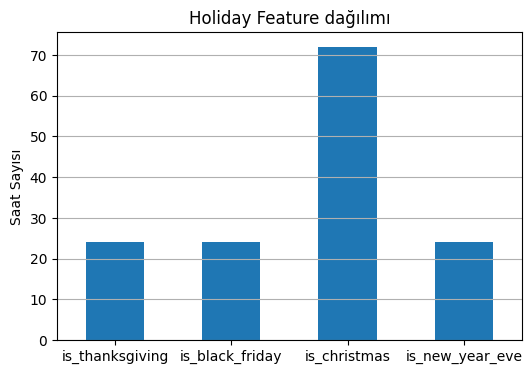

In [39]:
holiday_columns = [
    "is_thanksgiving",
    "is_black_friday",
    "is_christmas",
    "is_new_year_eve"
]

hourly_data[holiday_columns].sum().plot(
    kind="bar",
    figsize=(6,4),
    title="Holiday Feature dağılımı"
)

plt.ylabel("Saat Sayısı")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

In [40]:
hourly_data.head()

,tpep_pickup_datetime,trip_count,pickup_hour,pickup_dayofweek,pickup_month,pickup_day,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,is_weekend,is_rush_hour,is_thanksgiving,is_black_friday,is_christmas,is_new_year_eve
0,2015-01-01 00:00:00,26863,0,3,1,1,0.000000,1.000000,0.433884,-0.900969,0.5,0.866025,0,0,0,0,0,0
1,2015-01-01 01:00:00,30023,1,3,1,1,0.258819,0.965926,0.433884,-0.900969,0.5,0.866025,0,0,0,0,0,0
2,2015-01-01 02:00:00,26474,2,3,1,1,0.500000,0.866025,0.433884,-0.900969,0.5,0.866025,0,0,0,0,0,0
3,2015-01-01 03:00:00,22833,3,3,1,1,0.707107,0.707107,0.433884,-0.900969,0.5,0.866025,0,0,0,0,0,0
4,2015-01-01 04:00:00,15841,4,3,1,1,0.866025,0.500000,0.433884,-0.900969,0.5,0.866025,0,0,0,0,0,0


## --Saatlere göre ortalama trip sayısı--

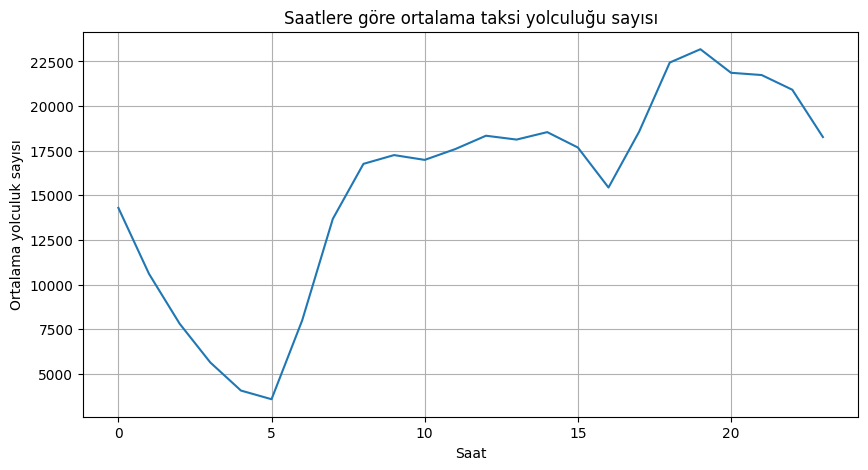

In [41]:
plt.figure(figsize=(10,5))
hourly_data.groupby("pickup_hour")["trip_count"].mean().plot()
plt.title("Saatlere göre ortalama taksi yolculuğu sayısı")
plt.xlabel("Saat")
plt.ylabel("Ortalama yolculuk sayısı")
plt.grid(True)
plt.show()

### taksi talebinin sabah erken saatlerde düşük, en yüksek talep yaklaşık 18:00–20:00 saatleri arasında gerçekleşmektedir

## --Haftanın günlerine göre ortalama trip sayısı--

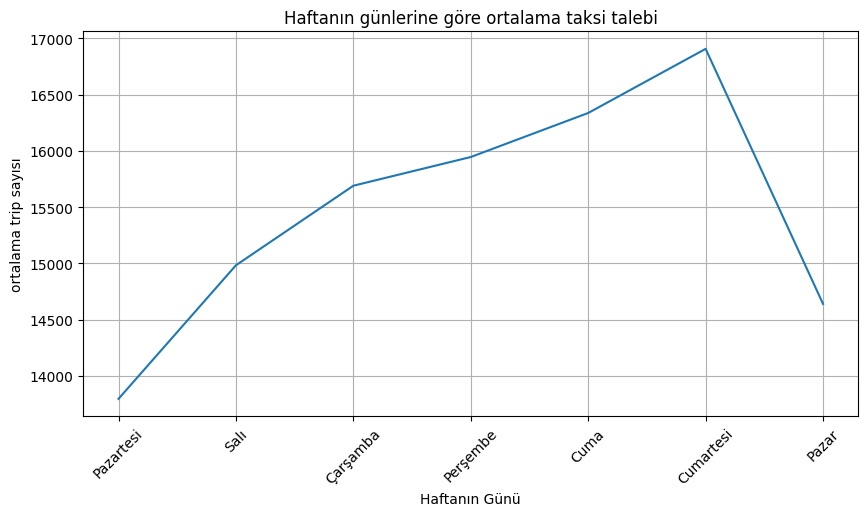

In [42]:
günler = [
    "Pazartesi",
    "Salı",
    "Çarşamba",
    "Perşembe",
    "Cuma",
    "Cumartesi",
    "Pazar" ]
hourly_data.groupby("pickup_dayofweek")["trip_count"].mean().plot(figsize=(10,5))
plt.title("Haftanın günlerine göre ortalama taksi talebi")
plt.xlabel("Haftanın Günü")
plt.ylabel("ortalama trip sayısı")
plt.xticks(range(7), günler, rotation=45)
plt.grid(True)
plt.show()

### grafikte hafta sonuna doğru talebin arttığı görülmekedir.Özellikle cumartesi günü en yüksek ortalama trip sayısına sahip.

## Model Training and Anomaly Detection
Bu bölümde saatlik taksi talebindeki anomalileri tespit etmek için Isolation Forest ve Random Forest modelleri kullanılmıştır.

In [43]:
# modelde kullanılacak özellikler
model_features = [
    "trip_count",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "pickup_day",
    "is_weekend",
    "is_rush_hour",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos"]
X = hourly_data[model_features]

### Isolation Forest
Isolation Forest modeli kullanılarak saatlik taksi talebindeki anomaliler tespit edilmiştir.
Isolation Forest modeli, saatlik taksi talebindeki sıra dışı gözlemleri tespit etmek için kullanılmıştır.
Model denetimsiz çalıştığı için anomali etiketlerine ihtiyaç duymaz.

In [44]:
from sklearn.ensemble import IsolationForest
# Isolation Forest modeli oluşturlması
iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)
# anomali tahmini yap
hourly_data["isolation_anomaly"] = iso_model.fit_predict(X)
# -1 anomali, 1 normal
hourly_data["isolation_anomaly"] = hourly_data["isolation_anomaly"].map({
    1: 0,
    -1: 1
})
hourly_data["isolation_anomaly"].value_counts()

isolation_anomaly
0    8672
1      88
Name: count, dtype: int64

## Farklı Contamination değerleri için anomali değeri
Ana modelde contamination=0.01 kullanmıştım daha sonra parametreleri incelemek için 0.001 ile 0.05 arasında farklı contamination değerleri denedim ve contamination arttıkça tespit edilen anomali sayısının da arttığını gözlemledim

In [45]:
contamination_values = [0.001, 0.005, 0.01, 0.02, 0.05]
results = []

for c in contamination_values:
    iso = IsolationForest(
        contamination=c,
        random_state=42 )
    preds = iso.fit_predict(X)
    anomaly_count = (preds == -1).sum()
    results.append({
        "Contamination": c,
        "Anomaly Count": anomaly_count
    })
results_df = pd.DataFrame(results)
results_df

,Contamination,Anomaly Count
0,0.001,9
1,0.005,44
2,0.010,88
3,0.020,176
4,0.050,438


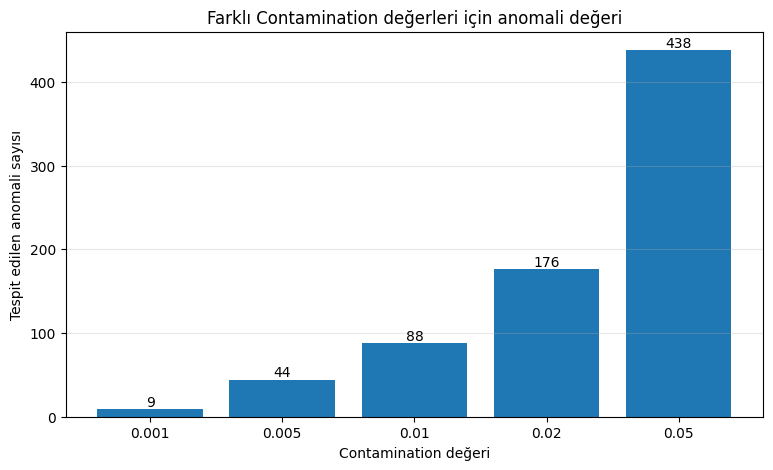

In [46]:
plt.figure(figsize=(9,5))

bars = plt.bar(
    results_df["Contamination"].astype(str),
    results_df["Anomaly Count"])
plt.xlabel("Contamination değeri")
plt.ylabel("Tespit edilen anomali sayısı")
plt.title("Farklı Contamination değerleri için anomali değeri")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha="center",
        va="bottom")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [47]:
# isolation forest ile bulunan anomalileri göster
hourly_data[hourly_data["isolation_anomaly"] == 1].head()

,tpep_pickup_datetime,trip_count,pickup_hour,pickup_dayofweek,pickup_month,pickup_day,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,is_weekend,is_rush_hour,is_thanksgiving,is_black_friday,is_christmas,is_new_year_eve,isolation_anomaly
0,2015-01-01 00:00:00,26863,0,3,1,1,0.000000,1.000000,0.433884,-0.900969,0.5,0.866025,0,0,0,0,0,0,1
1,2015-01-01 01:00:00,30023,1,3,1,1,0.258819,0.965926,0.433884,-0.900969,0.5,0.866025,0,0,0,0,0,0,1
67,2015-01-03 19:00:00,24239,19,5,1,3,-0.965926,0.258819,-0.974928,-0.222521,0.5,0.866025,1,1,0,0,0,0,1
79,2015-01-04 07:00:00,4005,7,6,1,4,0.965926,-0.258819,-0.781831,0.623490,0.5,0.866025,1,1,0,0,0,0,1
95,2015-01-04 23:00:00,9059,23,6,1,4,-0.258819,0.965926,-0.781831,0.623490,0.5,0.866025,1,0,0,0,0,0,1


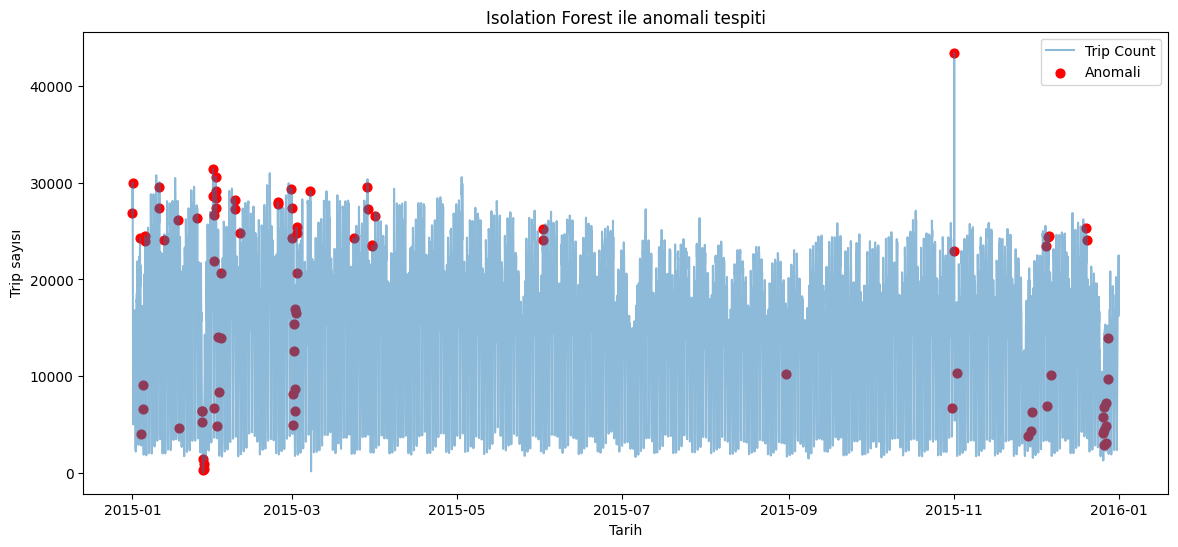

In [48]:
anomalies = hourly_data[
    hourly_data["isolation_anomaly"] == 1
]
plt.figure(figsize=(14,6))
plt.plot(
    hourly_data["tpep_pickup_datetime"],
    hourly_data["trip_count"],
    alpha=0.5,
    label="Trip Count")
plt.scatter(
    anomalies["tpep_pickup_datetime"],
    anomalies["trip_count"],
    color="red",
    s=40,
    label="Anomali")
plt.title("Isolation Forest ile anomali tespiti")
plt.xlabel("Tarih")
plt.ylabel("Trip sayısı")
plt.legend()
plt.show()

Isolation Forest modeli 88 adet anomali buldu.

Kırmızı noktalar model tarafından anomali olarak işaretlenen saatleri göstermektedir

## Random Forest Regressor
Bu bölümde Random Forest Regressor modeli kullanılarak saatlik trip sayısı tahmin edilmiştir.
Gerçek değer ile tahmin edilen değer arasındaki fark büyükse bu gözlemler anomali olarak değerlendirilmiştir.

In [49]:
from sklearn.model_selection import train_test_split
y = hourly_data["trip_count"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False)

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [51]:
# modelde kullanılacak özellikler
model_features = [
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "pickup_day",
    "is_weekend",
    "is_rush_hour",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "is_thanksgiving",
    "is_black_friday",
    "is_christmas",
    "is_new_year_eve"]
X = hourly_data[model_features]
# tahmin edilecek hedef değişken
y = hourly_data["trip_count"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False)

In [53]:
# Random Forest Regressor modeli
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train);

In [54]:
# test verisi üzerinde tahmin yapılması
y_pred = rf_model.predict(X_test)

In [55]:
# ortalama mutlak hata
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", round(mae, 2))

MAE: 1608.23


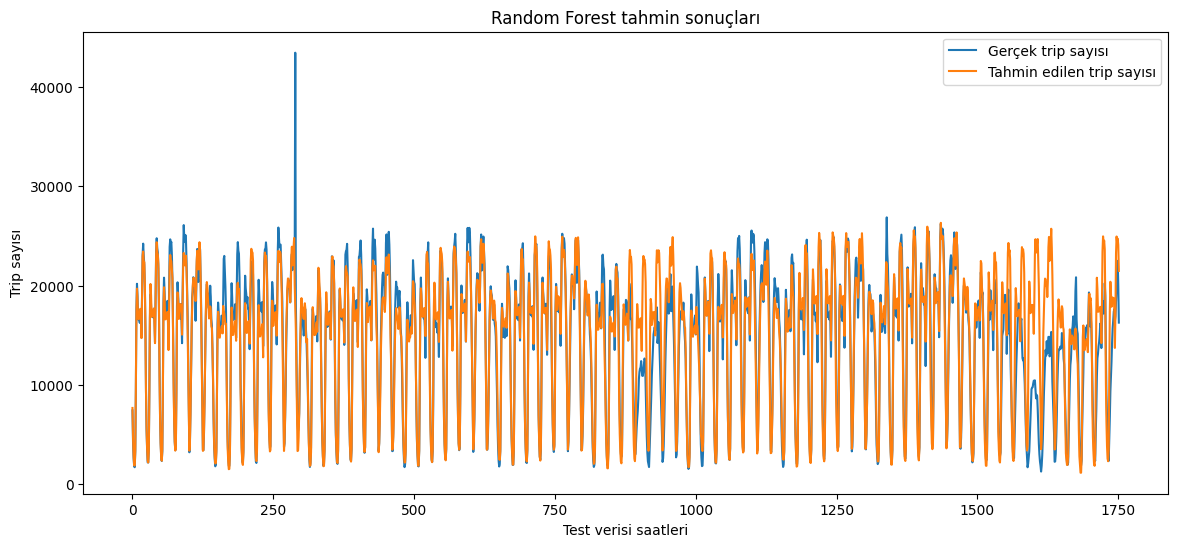

In [56]:
plt.figure(figsize=(14,6))
plt.plot(
y_test.values,
label="Gerçek trip sayısı")
plt.plot(
y_pred,
label="Tahmin edilen trip sayısı")
plt.title("Random Forest tahmin sonuçları")
plt.xlabel("Test verisi saatleri")
plt.ylabel("Trip sayısı")
plt.legend()
plt.show()

In [57]:
# tahminleri test verisine ekle
test_data = hourly_data.iloc[X_test.index].copy()
test_data["predicted_trip_count"] = y_pred
# tahmin hatası
test_data["prediction_error"] = abs(
    test_data["trip_count"] -
    test_data["predicted_trip_count"])

In [58]:
test_data["prediction_error"].describe()

count     1752.000000
mean      1608.228031
std       2314.752275
min          1.230000
25%        318.210000
50%        880.275000
75%       1849.355000
max      25819.570000
Name: prediction_error, dtype: float64

In [59]:
threshold = test_data["prediction_error"].quantile(0.99)
test_data["rf_anomaly"] = (
    test_data["prediction_error"] > threshold
).astype(int)
test_data["rf_anomaly"].value_counts()

rf_anomaly
0    1734
1      18
Name: count, dtype: int64

In [60]:
test_data[
    test_data["rf_anomaly"] == 1
].head()

,tpep_pickup_datetime,trip_count,pickup_hour,pickup_dayofweek,pickup_month,pickup_day,hour_sin,hour_cos,day_sin,day_cos,...,is_weekend,is_rush_hour,is_thanksgiving,is_black_friday,is_christmas,is_new_year_eve,isolation_anomaly,predicted_trip_count,prediction_error,rf_anomaly
7297,2015-11-01 01:00:00,43452,1,6,11,1,0.258819,0.965926,-0.781831,0.623490,...,1,0,0,0,0,0,1,17632.43,25819.57,1
7904,2015-11-26 08:00:00,6619,8,3,11,26,0.866025,-0.500000,0.433884,-0.900969,...,0,1,1,0,0,0,0,18139.81,11520.81,1
7915,2015-11-26 19:00:00,11440,19,3,11,26,-0.965926,0.258819,0.433884,-0.900969,...,0,1,1,0,0,0,0,22984.05,11544.05,1
7927,2015-11-27 07:00:00,5183,7,4,11,27,0.965926,-0.258819,-0.433884,-0.900969,...,0,1,0,1,0,0,0,16297.21,11114.21,1
7928,2015-11-27 08:00:00,6971,8,4,11,27,0.866025,-0.500000,-0.433884,-0.900969,...,0,1,0,1,0,0,0,18659.98,11688.98,1


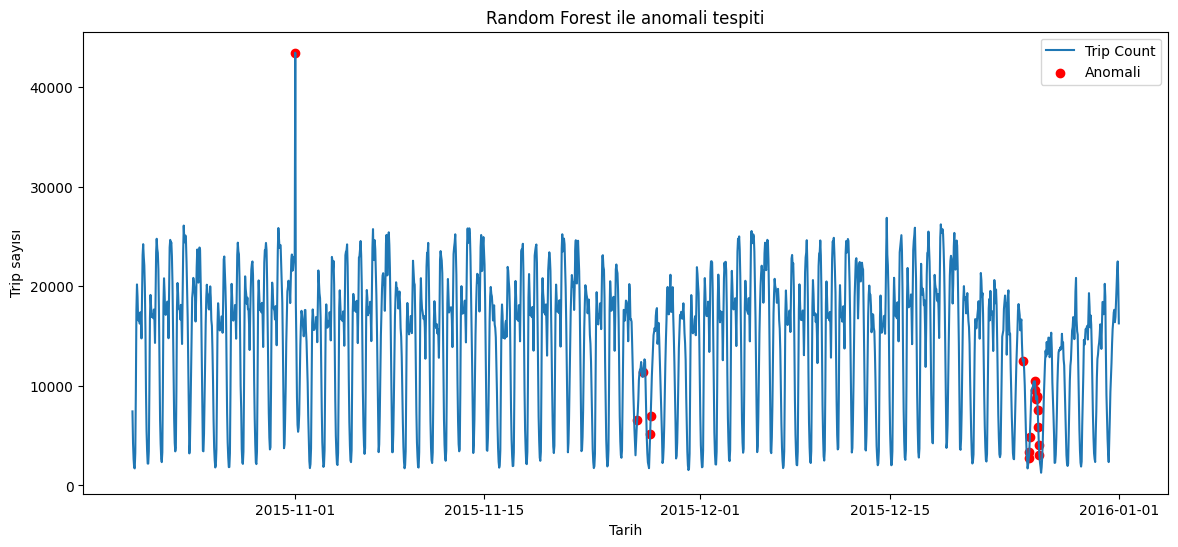

In [61]:
rf_anomalies = test_data[
    test_data["rf_anomaly"] == 1
]
plt.figure(figsize=(14,6))
plt.plot(
test_data["tpep_pickup_datetime"],
test_data["trip_count"],
label="Trip Count")
plt.scatter(
rf_anomalies["tpep_pickup_datetime"],
rf_anomalies["trip_count"],
color="red",
label="Anomali")
plt.title("Random Forest ile anomali tespiti")
plt.xlabel("Tarih")
plt.ylabel("Trip sayısı")
plt.legend()
plt.show()

In [62]:
# en yüksek trip sayılarını göster
hourly_data.sort_values(
    by="trip_count",
    ascending=False
).head(10)

,tpep_pickup_datetime,trip_count,pickup_hour,pickup_dayofweek,pickup_month,pickup_day,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,is_weekend,is_rush_hour,is_thanksgiving,is_black_friday,is_christmas,is_new_year_eve,isolation_anomaly
7297,2015-11-01 01:00:00,43452,1,6,11,1,0.258819,0.965926,-0.781831,0.623490,-0.500000,8.660254e-01,1,0,0,0,0,0,1
715,2015-01-30 19:00:00,31412,19,4,1,30,-0.965926,0.258819,-0.433884,-0.900969,0.500000,8.660254e-01,0,1,0,0,0,0,1
1219,2015-02-20 19:00:00,30995,19,4,2,20,-0.965926,0.258819,-0.433884,-0.900969,0.866025,5.000000e-01,0,1,0,0,0,0,0
211,2015-01-09 19:00:00,30783,19,4,1,9,-0.965926,0.258819,-0.433884,-0.900969,0.500000,8.660254e-01,0,1,0,0,0,0,0
739,2015-01-31 19:00:00,30637,19,5,1,31,-0.965926,0.258819,-0.974928,-0.222521,0.500000,8.660254e-01,1,1,0,0,0,0,1
2923,2015-05-02 19:00:00,30584,19,5,5,2,-0.965926,0.258819,-0.974928,-0.222521,0.500000,-8.660254e-01,1,1,0,0,0,0,0
379,2015-01-16 19:00:00,30490,19,4,1,16,-0.965926,0.258819,-0.433884,-0.900969,0.500000,8.660254e-01,0,1,0,0,0,0,0
2087,2015-03-28 23:00:00,30365,23,5,3,28,-0.258819,0.965926,-0.974928,-0.222521,1.000000,6.123234e-17,1,0,0,0,0,0,0
716,2015-01-30 20:00:00,30165,20,4,1,30,-0.866025,0.500000,-0.433884,-0.900969,0.500000,8.660254e-01,0,0,0,0,0,0,0
239,2015-01-10 23:00:00,30074,23,5,1,10,-0.258819,0.965926,-0.974928,-0.222521,0.500000,8.660254e-01,1,0,0,0,0,0,0


In [63]:
# 40000 üzerindeki kayıtları göster
hourly_data[
    hourly_data["trip_count"] > 40000
]

,tpep_pickup_datetime,trip_count,pickup_hour,pickup_dayofweek,pickup_month,pickup_day,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,is_weekend,is_rush_hour,is_thanksgiving,is_black_friday,is_christmas,is_new_year_eve,isolation_anomaly
7297,2015-11-01 01:00:00,43452,1,6,11,1,0.258819,0.965926,-0.781831,0.62349,-0.5,0.866025,1,0,0,0,0,0,1


### En yüksek trip sayısı 2015-11-01 01:00 saatinde görülmüştür. Bu tarih ABD'de yaz saati uygulamasının sona erdiği gündür.saatler 02:00 → 01:00  olarak geri alındı ve 01:00 saati iki kez yaşanmış.
Bu nedenle hem Isolation Forest hem de Random Forest modeli tarafından anomali olarak işaretlenmiştir

## Saatlerin ileri alınmasının kontrolü
ABD'de 2015 yılında yaz saati uygulaması 8 Mart tarihinde başlamıştır. Bu tarihte saatler ileri alınmıştır. 02:00 → 03:00

## Random Forest kontrolü
Random Forest'ta shuffle=False kullandığım için veri kronolojik olarak sıralanmıştır. model yılın ilk %80'i ile eğitilmiş, son %20'si ile test etmiştim.bu nedenle test kümesi yalnızca kasım ve aralık aylarını içeriyor. 8 Mart test verisinde olmadığı için saatlerin ileri alınmasını RF ile değerlendiremedim


In [64]:
# saatlerin ileri alındığı günü inceliyorum 
hourly_data[
    (hourly_data["tpep_pickup_datetime"] >= "2015-03-08") &
    (hourly_data["tpep_pickup_datetime"] < "2015-03-09")
][["tpep_pickup_datetime", "trip_count"]]

,tpep_pickup_datetime,trip_count
1584,2015-03-08 00:00:00,26226
1585,2015-03-08 01:00:00,23520
1586,2015-03-08 02:00:00,152
1587,2015-03-08 03:00:00,21035
1588,2015-03-08 04:00:00,14382
1589,2015-03-08 05:00:00,6870
1590,2015-03-08 06:00:00,4514
1591,2015-03-08 07:00:00,5517
1592,2015-03-08 08:00:00,8094
1593,2015-03-08 09:00:00,12389


In [65]:
# 8 mart gününde Isolation Forest anomalisi var mı kontrol ediyorum
hourly_data[
    (hourly_data["isolation_anomaly"] == 1) &
    (hourly_data["pickup_month"] == 3) &
    (hourly_data["pickup_day"] == 8)
][["tpep_pickup_datetime", "trip_count", "isolation_anomaly"]]

,tpep_pickup_datetime,trip_count,isolation_anomaly


In [66]:
# 02:00 saatinişn kontrolü
hourly_data[
    (hourly_data["pickup_month"] == 3) &
    (hourly_data["pickup_day"] == 8) &
    (hourly_data["pickup_hour"] == 2)
][["tpep_pickup_datetime", "trip_count"]]

,tpep_pickup_datetime,trip_count
1586,2015-03-08 02:00:00,152


In [67]:
# 8 mart günündeki en yüksek trip sayılarını gösterilmesi
hourly_data[
    (hourly_data["pickup_month"] == 3) &
    (hourly_data["pickup_day"] == 8)
].sort_values(
    by="trip_count",
    ascending=False
)[["tpep_pickup_datetime", "trip_count"]].head(10)

,tpep_pickup_datetime,trip_count
1584,2015-03-08 00:00:00,26226
1585,2015-03-08 01:00:00,23520
1597,2015-03-08 13:00:00,22115
1596,2015-03-08 12:00:00,21745
1598,2015-03-08 14:00:00,21392
1587,2015-03-08 03:00:00,21035
1602,2015-03-08 18:00:00,20316
1603,2015-03-08 19:00:00,20274
1595,2015-03-08 11:00:00,19597
1599,2015-03-08 15:00:00,19270


### --8 Mart 2015 tarihinde saatler ileri alındığı için 02:00 saatindeki trip sayısı diğer saatlere göre oldukça düşük ancak Isolation Forest modeli bu durumu anomali olarak değerlendirmemiştir.

## Kasım ve Aralık ayındaki anomalilerin incelenmesi
### Bu anomalilerin resmi tatiller veya özel günlerle ilişkili olup olmadığı kontrol edilmesi

In [68]:
# Kasım sonundaki anomalileri gösteriyorum
rf_anomalies[
    (rf_anomalies["tpep_pickup_datetime"] >= "2015-11-25") &
    (rf_anomalies["tpep_pickup_datetime"] <= "2015-11-30")
][
    ["tpep_pickup_datetime", "trip_count"]
].sort_values("tpep_pickup_datetime")

,tpep_pickup_datetime,trip_count
7904,2015-11-26 08:00:00,6619
7915,2015-11-26 19:00:00,11440
7927,2015-11-27 07:00:00,5183
7928,2015-11-27 08:00:00,6971


In [69]:
# 31 Aralık saatlik trip sayıları
hourly_data[
    (hourly_data["tpep_pickup_datetime"] >= "2015-12-31") &
    (hourly_data["tpep_pickup_datetime"] < "2016-01-01")
][
    ["tpep_pickup_datetime", "trip_count"]
]

,tpep_pickup_datetime,trip_count
8736,2015-12-31 00:00:00,13370
8737,2015-12-31 01:00:00,9115
8738,2015-12-31 02:00:00,6818
8739,2015-12-31 03:00:00,4677
8740,2015-12-31 04:00:00,3223
8741,2015-12-31 05:00:00,2349
8742,2015-12-31 06:00:00,4387
8743,2015-12-31 07:00:00,6736
8744,2015-12-31 08:00:00,9349
8745,2015-12-31 09:00:00,10751


In [70]:
# Christmas ve yılbaşı dönemini birlikte gösteriyorum
hourly_data[
    (hourly_data["pickup_month"] == 12) &
    (hourly_data["pickup_day"].isin([24, 25, 26, 31]))
][
    ["tpep_pickup_datetime", "trip_count"]
]

,tpep_pickup_datetime,trip_count
8568,2015-12-24 00:00:00,9175
8569,2015-12-24 01:00:00,6886
8570,2015-12-24 02:00:00,4896
8571,2015-12-24 03:00:00,3251
8572,2015-12-24 04:00:00,2685
...,...,...
8755,2015-12-31 19:00:00,19932
8756,2015-12-31 20:00:00,21571
8757,2015-12-31 21:00:00,22496
8758,2015-12-31 22:00:00,20129


In [71]:
rf_anomalies[
    rf_anomalies["tpep_pickup_datetime"] == "2015-12-31 08:00:00"
][
    [
        "tpep_pickup_datetime",
        "trip_count",
        "prediction_error"
    ]
]

,tpep_pickup_datetime,trip_count,prediction_error


### Sonuç

### Kasım ve Aralık aylarında tespit edilen anomalilerin büyük bölümü ABD'deki özel günlere denk gelmektedir.

 - 26 Kasım → şükran günü
 - 27 Kasım → Black Friday
 - 24-26 Aralık → Christmas
 - 31 Aralık → Yılbaşı 

### Özellikle 31 Aralık saat 08:00'de modelin tahmin hatası oldukça yüksektir. Bunun nedeni yılbaşı döneminde sabah saatlerindeki taksi talebinin normal iş günlerinden farklı olmasıdır. Bu nedenle Random Forest modeli bu zamanı anomali olarak işaretlemiştir.

## Lagged Features

In [72]:
# 1 saat önceki trip sayısı
hourly_data["trip_count_lag_1h"] = hourly_data["trip_count"].shift(1)

# 1 hafta önce aynı saatteki trip sayısı
hourly_data["trip_count_lag_1week"] = hourly_data["trip_count"].shift(24 * 7)

hourly_data[
    [
        "tpep_pickup_datetime",
        "trip_count",
        "trip_count_lag_1h",
        "trip_count_lag_1week"
    ]
].head(180)

,tpep_pickup_datetime,trip_count,trip_count_lag_1h,trip_count_lag_1week
0,2015-01-01 00:00:00,26863,NaN,NaN
1,2015-01-01 01:00:00,30023,26863.0,NaN
2,2015-01-01 02:00:00,26474,30023.0,NaN
3,2015-01-01 03:00:00,22833,26474.0,NaN
4,2015-01-01 04:00:00,15841,22833.0,NaN
...,...,...,...,...
175,2015-01-08 07:00:00,21094,11055.0,5283.0
176,2015-01-08 08:00:00,25535,21094.0,5003.0
177,2015-01-08 09:00:00,23214,25535.0,6311.0
178,2015-01-08 10:00:00,19865,23214.0,9094.0


In [73]:
hourly_data = hourly_data.dropna().reset_index(drop=True)

In [74]:
model_features = [
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "pickup_day",
    "is_weekend",
    "is_rush_hour",
    "hour_sin",
    "hour_cos",
    "day_sin",
    "day_cos",
    "month_sin",
    "month_cos",
    "trip_count_lag_1h",
    "trip_count_lag_1week",
    "is_thanksgiving",
    "is_black_friday",
    "is_christmas",
    "is_new_year_eve"
]

In [75]:
# Lag Feature Kontrolü
hourly_data[[
    "trip_count",
    "trip_count_lag_1h",
    "trip_count_lag_1week"
]].head()

,trip_count,trip_count_lag_1h,trip_count_lag_1week
0,9566,15399.0,26863.0
1,5601,9566.0,30023.0
2,3370,5601.0,26474.0
3,2277,3370.0,22833.0
4,1994,2277.0,15841.0


In [76]:
print(hourly_data.shape)

(8592, 21)


### -Modele 1 saat önceki ve 1 hafta önceki trip sayıları yeni özellikler olarak eklendi. Lag feature oluşturulduktan sonra oluşan eksik (NaN) değerler temizlendi ve veri model eğitimi için hazır hale getirildi.

# Tahminleme Modelleri

Geçmişteki yolculuk sayıları gelecekteki yolculuk sayılarını etkileyebilir. Bu nedenle modele geçmiş bilgiyi de vermek için lag feature kullandım

In [77]:
# lag feature'lar dahil model_features listesi ile X ve y oluşturuluyor
X = hourly_data[model_features]
y = hourly_data["trip_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False)

## Random Forest Regressor
Random Forest i saatlik taksi talebini tahmin etmek için kullandım çünkü doğrusal olmayan ilişkileri öğrenebiliyor ve feature importance verebiliyor. modelin tahmin yaparken hangi özelliklere daha fazla önem verdiğini görmek için feature importance kullandım

In [93]:
# Random Forest Regressor modeli
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=45
)
rf_model.fit(X_train, y_train)

# test verisi üzerinde tahmin yapılması
rf_pred = rf_model.predict(X_test)

importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance

,Feature,Importance
13,trip_count_lag_1week,0.866057
12,trip_count_lag_1h,0.093378
7,hour_cos,0.009604
6,hour_sin,0.007684
0,pickup_hour,0.007571
3,pickup_day,0.002999
2,pickup_month,0.002249
1,pickup_dayofweek,0.001908
5,is_rush_hour,0.001904
8,day_sin,0.001856


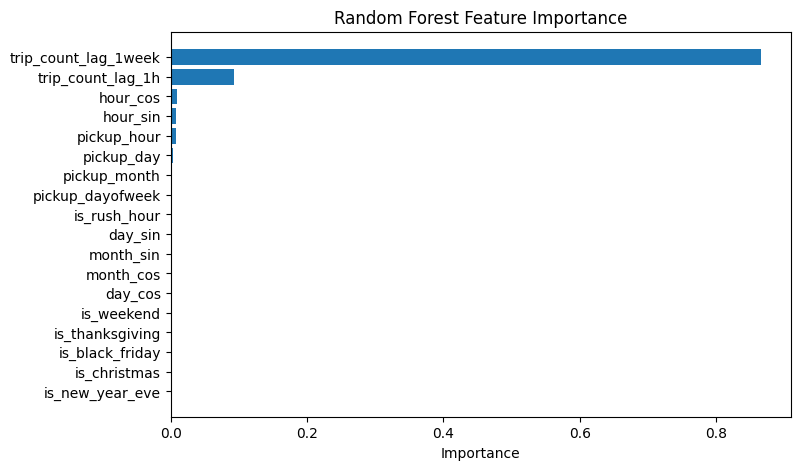

In [94]:
plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

### grafikte görüldüğü gibbi Random Forest modeli tahmin yaparken en fazla **trip_count_lag_1week** değişkenine önem vermiştir. Bu da bir hafta önceki aynı saatteki yolculuk sayısının gelecekteki taksi talebini tahmin etmede en etkili özellik olduğunu göstermektedir

In [95]:
# MAE  (ortalama mutlak hata)
rf_mae = mean_absolute_error(y_test, rf_pred)
print("Random Forest MAE:", round(rf_mae, 2))

Random Forest MAE: 773.23


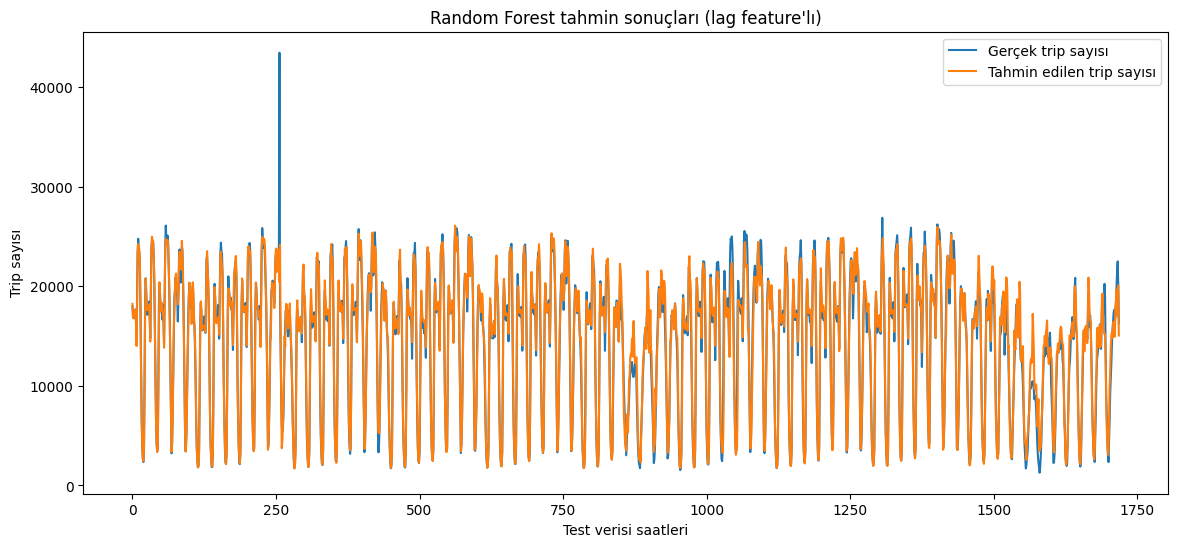

In [96]:
plt.figure(figsize=(14,6))
plt.plot(
y_test.values,
label="Gerçek trip sayısı")
plt.plot(
rf_pred,
label="Tahmin edilen trip sayısı")
plt.title("Random Forest tahmin sonuçları (lag feature'lı)")
plt.xlabel("Test verisi saatleri")
plt.ylabel("Trip sayısı")
plt.legend()
plt.show()

### grafikte turuncu çizgi ile mavi çizgi çoğu yerde birbirini takip ediyor bu modelin başarılı tahmin yaptığını gösteriyor

## Support Vector Regression (SVR)
SVR modeli mesafeye dayalı çalıştığı için özelliklerin ölçeklenmesi gerekiyor özellikleri aynı ölçeğe getirerek modelin daha sağlıklı öğrenmesini sağladım. Bu nedenle StandardScaler ile X_train ve X_test ölçeklendirildi.

In [97]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

In [98]:
# özellikleri ölçeklendiriyorum
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [99]:
# SVR modeli
svr_model = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1
)
svr_model.fit(X_train_scaled, y_train)

# test verisi üzerinde tahmin yapılması
svr_pred = svr_model.predict(X_test_scaled)

In [100]:
# ortalama mutlak hata
svr_mae = mean_absolute_error(y_test, svr_pred)
print("SVR MAE:", round(svr_mae, 2))

SVR MAE: 2059.87


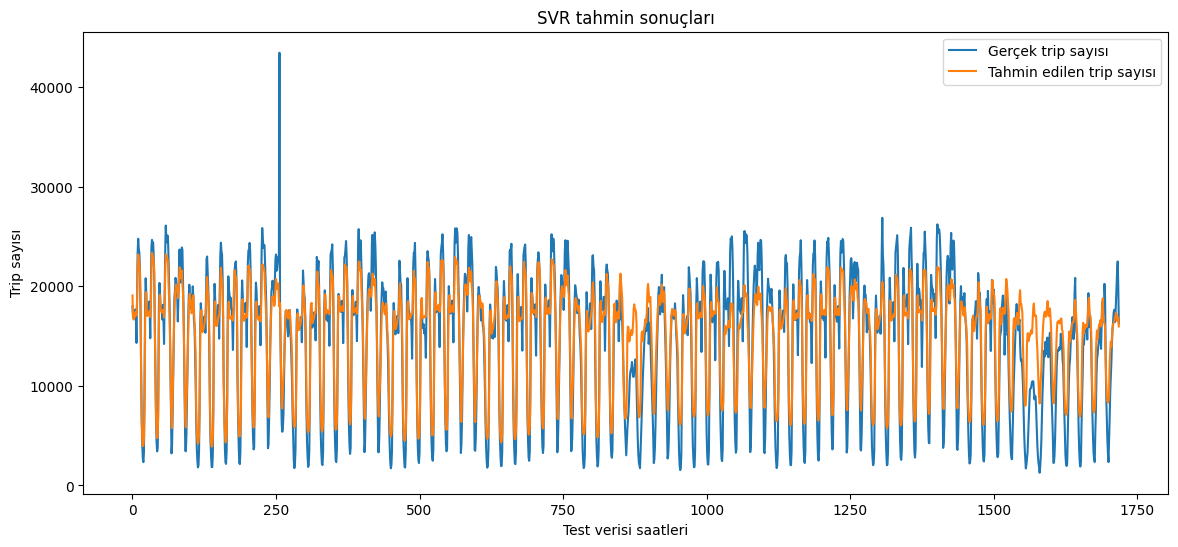

In [101]:
plt.figure(figsize=(14,6))
plt.plot(
y_test.values,
label="Gerçek trip sayısı")
plt.plot(
svr_pred,
label="Tahmin edilen trip sayısı")
plt.title("SVR tahmin sonuçları")
plt.xlabel("Test verisi saatleri")
plt.ylabel("Trip sayısı")
plt.legend()
plt.show()

### SVR genel eğilimi yakalıyor fakat bazı saatlerde gerçek değerlere göre daha fazla sapma olduğu görülüyor

## Model Karşılaştırması
Random Forest ve SVR modellerinin MAE değerleri karşılaştırılmıştır.

In [103]:
# iki modelin MAE değerlerinin karşılaştırılması
comparison = pd.DataFrame({
    "Model": ["Random Forest", "SVR"],
    "MAE": [rf_mae, svr_mae]
})
comparison

,Model,MAE
0,Random Forest,773.228278
1,SVR,2059.868571


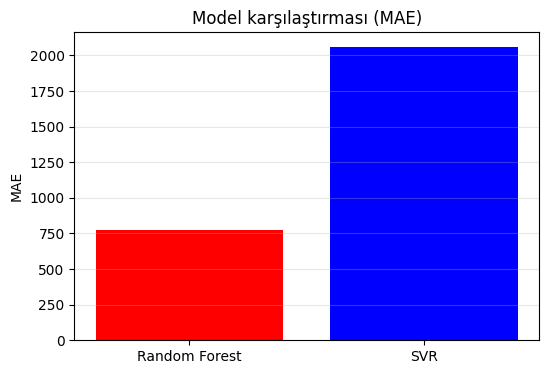

In [104]:
plt.figure(figsize=(6,4))
plt.bar(
    comparison["Model"],
    comparison["MAE"],
    color=["red", "blue"])
plt.title("Model karşılaştırması (MAE)")
plt.ylabel("MAE")
plt.grid(axis="y", alpha=0.3)
plt.show()